In [70]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [71]:
spam_data = pd.read_csv('D:\\Educational Data\\Data Science Projects\\spam classifier\\spam.csv', encoding='latin-1')

In [72]:
spam_data.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [73]:
spam_data.shape

(5572, 5)

# 1.Data Cleaning

In [74]:
spam_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [75]:
# Check for missing values
spam_data.isnull().sum()

v1               0
v2               0
Unnamed: 2    5522
Unnamed: 3    5560
Unnamed: 4    5566
dtype: int64

In [76]:
#drop the last 3 columns as they are not needed
spam_data.drop(columns=['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], inplace=True)

In [77]:
spam_data.head()

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [78]:
spam_data.sample(5)

,v1,v2
3901,ham,"Right on brah, see you later"
367,spam,Here is your discount code RP176781. To stop f...
4269,ham,Great. Hope you are using your connections fro...
3814,ham,"Not yet chikku..k, then wat abt tht guy did he..."
922,ham,It shall be fine. I have avalarr now. Will hol...


In [79]:
#Renaming the columns for better understanding
spam_data.rename(columns={'v1': 'label', 'v2': 'message'}, inplace=True)
spam_data.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [80]:
#Apply label encoding to the 'label' column
from sklearn.preprocessing import LabelEncoder    
encoder = LabelEncoder()
spam_data['label'] = encoder.fit_transform(spam_data['label'])

In [81]:
spam_data.head()

,label,message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [82]:
#checks for missing values again after dropping the unnecessary columns 
spam_data.isnull().sum()

label      0
message    0
dtype: int64

In [83]:
# Check for duplicate values
spam_data.duplicated().sum()

np.int64(403)

In [84]:
# Drop duplicate values
spam_data = spam_data.drop_duplicates(keep='first')

In [85]:
# Check for duplicate values again after dropping duplicates
spam_data.duplicated().sum()

np.int64(0)

In [86]:
spam_data.shape

(5169, 2)

# 2.EDA 



In [87]:
spam_data['label'].value_counts()

label
0    4516
1     653
Name: count, dtype: int64

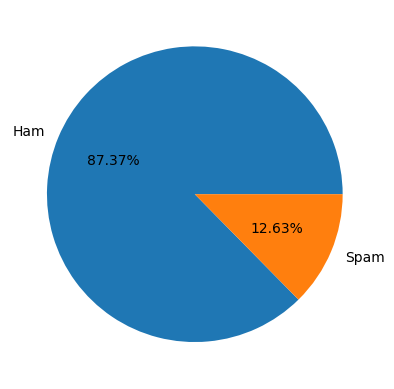

In [88]:
plt.pie(spam_data['label'].value_counts(), labels=['Ham', 'Spam'], autopct='%0.2f%%')
plt.show()

In [89]:
# Data is imbalaned 
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\MR.Laptops\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\MR.Laptops\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [90]:
!pip install nltk


[notice] A new release of pip is available: 23.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [91]:
spam_data['num_chars'] = spam_data['message'].apply(len)

In [92]:
spam_data['num_chars']

0       111
1        29
2       155
3        49
4        61
       ... 
5567    161
5568     37
5569     57
5570    125
5571     26
Name: num_chars, Length: 5169, dtype: int64

In [93]:
spam_data.head()

,label,message,num_chars
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [94]:
#num of words in each message
spam_data['num_words'] = spam_data['message'].apply(lambda x: len(nltk.word_tokenize(x)))

In [95]:
spam_data.head()

,label,message,num_chars,num_words
0,0,"Go until jurong point, crazy.. Available only ...",111,24
1,0,Ok lar... Joking wif u oni...,29,8
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37
3,0,U dun say so early hor... U c already then say...,49,13
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15


In [96]:
#num of sentences in each message   
spam_data['num_sents'] = spam_data['message'].apply(lambda x: len(nltk.sent_tokenize(x)))

In [97]:
spam_data.head()

,label,message,num_chars,num_words,num_sents
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [98]:
spam_data[['num_chars', 'num_words', 'num_sents']].describe()

,num_chars,num_words,num_sents
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.455794,1.965564
std,58.236293,13.324758,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [99]:
# Compare the statistics of ham and spam messages   
spam_data[spam_data['label'] == 0][['num_chars', 'num_words', 'num_sents']].describe()

,num_chars,num_words,num_sents
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [100]:
spam_data[spam_data['label'] == 1][['num_chars', 'num_words', 'num_sents']].describe()

,num_chars,num_words,num_sents
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


<Axes: xlabel='num_chars', ylabel='Count'>

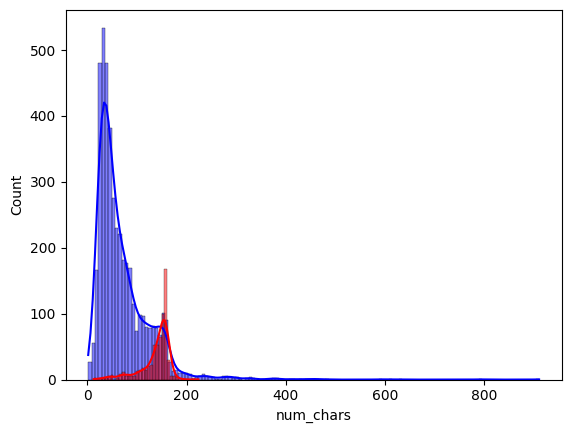

In [101]:
sns.histplot(spam_data[spam_data['label'] == 0]['num_chars'], color='blue', label='Ham', kde=True)
sns.histplot(spam_data[spam_data['label'] == 1]['num_chars'], color='red', label='Spam', kde=True)

<Axes: xlabel='num_words', ylabel='Count'>

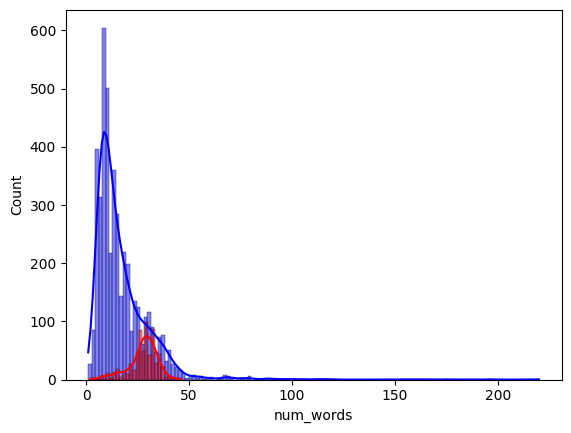

In [102]:
sns.histplot(spam_data[spam_data['label'] == 0]['num_words'], color='blue', label='Ham', kde=True)
sns.histplot(spam_data[spam_data['label'] == 1]['num_words'], color='red', label='Spam', kde=True)

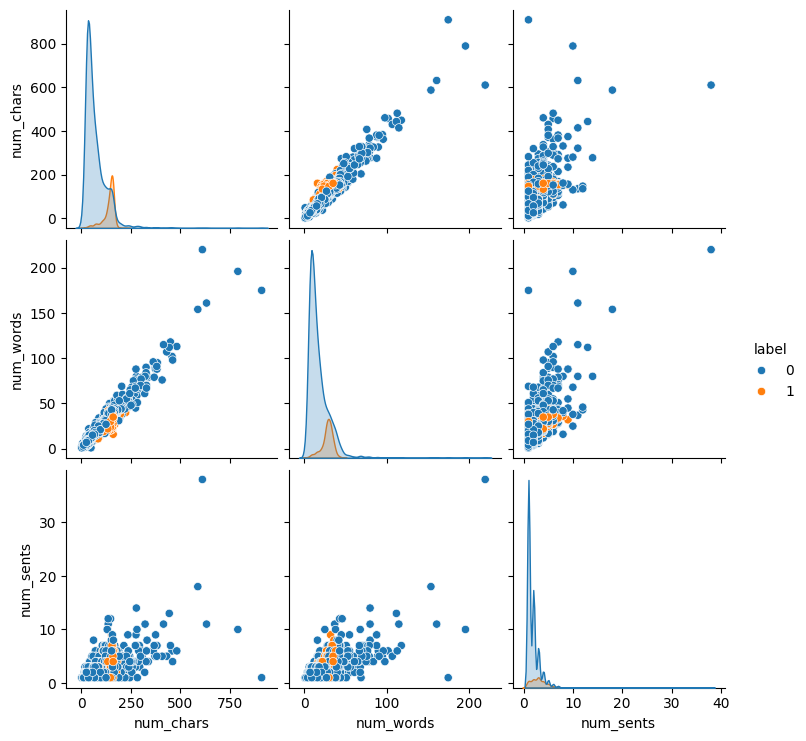

In [103]:
sns.pairplot(spam_data, hue='label')

<Axes: >

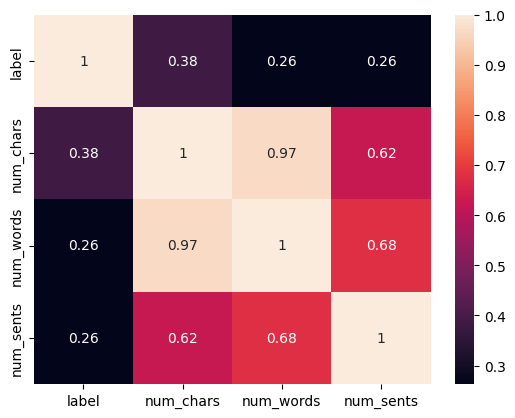

In [104]:
sns.heatmap(spam_data.corr(numeric_only=True), annot=True)

# 3.Data Preprocessing

In [105]:

import string
import nltk
nltk.download('stopwords')
nltk.download('punkt')

def transform_message(text):
    text = text.lower()
    text = nltk.word_tokenize(text)
    y = []
    for i in text:
        if i.isalnum():
            y.append(i)
    text = y[:]
    y.clear()

    for i in text:
        if i not in nltk.corpus.stopwords.words('english') and i not in string.punctuation:
            y.append(i)
    
    text = y[:]
    y.clear()
    
    for i in text:
        y.append(nltk.stem.PorterStemmer().stem(i))

    return " ".join(y)

spam_data['Transformed_Message'] = spam_data['message'].apply(transform_message)
spam_data.head()







[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\MR.Laptops\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\MR.Laptops\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


,label,message,num_chars,num_words,num_sents,Transformed_Message
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [106]:
!pip install wordcloud



[notice] A new release of pip is available: 23.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


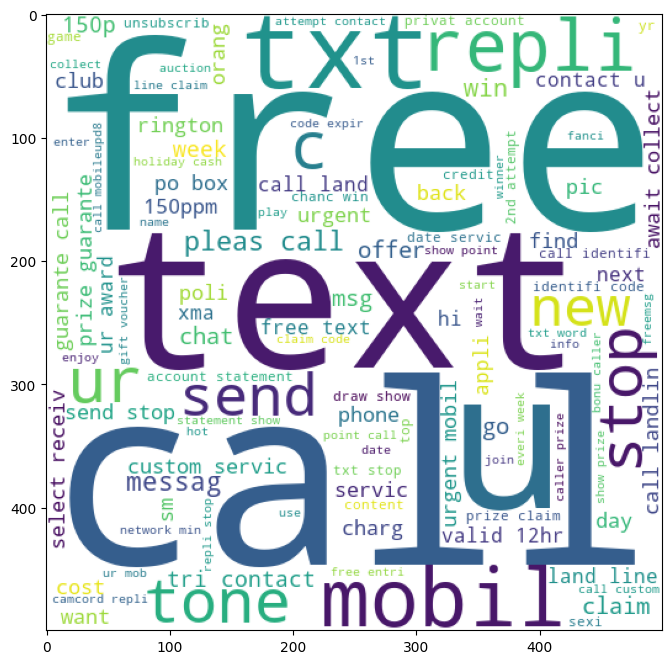

In [107]:
from wordcloud import WordCloud
spam_wc = WordCloud(width=500, height=500,min_font_size=10,background_color='white').generate(spam_data[spam_data['label'] == 1]['Transformed_Message'].str.cat(sep=" "))
plt.figure(figsize=(15, 8))
plt.imshow(spam_wc)

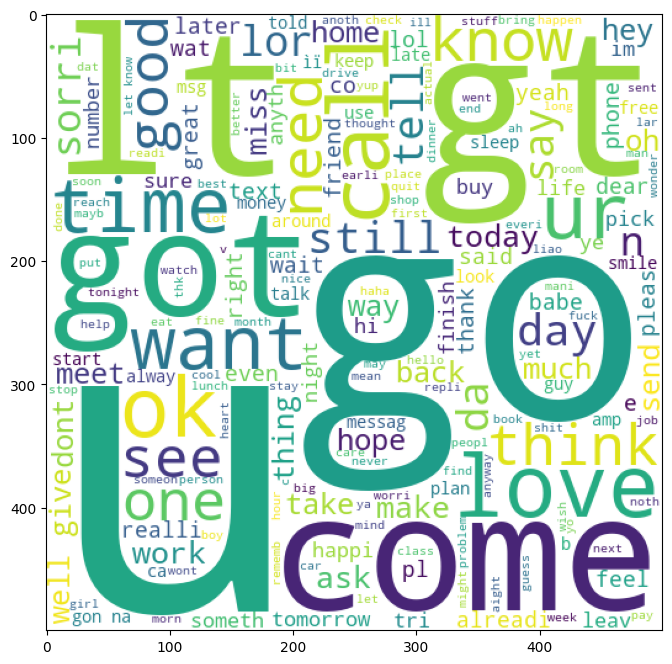

In [108]:
ham_wc = WordCloud(width=500, height=500,min_font_size=10,background_color='white').generate(spam_data[spam_data['label'] == 0]['Transformed_Message'].str.cat(sep=" "))
plt.figure(figsize=(15, 8))
plt.imshow(ham_wc)

In [109]:
# Most repeating words in spam messages
spam_corpus = []
for word in spam_data[spam_data['label'] == 1]['Transformed_Message']:
    for i in word.split():
        spam_corpus.append(i)
len(spam_corpus)



9939

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29],
 [Text(0, 0, 'call'),
  Text(1, 0, 'free'),
  Text(2, 0, '2'),
  Text(3, 0, 'txt'),
  Text(4, 0, 'text'),
  Text(5, 0, 'u'),
  Text(6, 0, 'ur'),
  Text(7, 0, 'mobil'),
  Text(8, 0, 'stop'),
  Text(9, 0, 'repli'),
  Text(10, 0, 'claim'),
  Text(11, 0, '4'),
  Text(12, 0, 'prize'),
  Text(13, 0, 'get'),
  Text(14, 0, 'new'),
  Text(15, 0, 'servic'),
  Text(16, 0, 'tone'),
  Text(17, 0, 'send'),
  Text(18, 0, 'urgent'),
  Text(19, 0, 'nokia'),
  Text(20, 0, 'contact'),
  Text(21, 0, 'award'),
  Text(22, 0, 'phone'),
  Text(23, 0, 'cash'),
  Text(24, 0, 'pleas'),
  Text(25, 0, 'week'),
  Text(26, 0, 'win'),
  Text(27, 0, 'c'),
  Text(28, 0, 'collect'),
  Text(29, 0, 'min')])

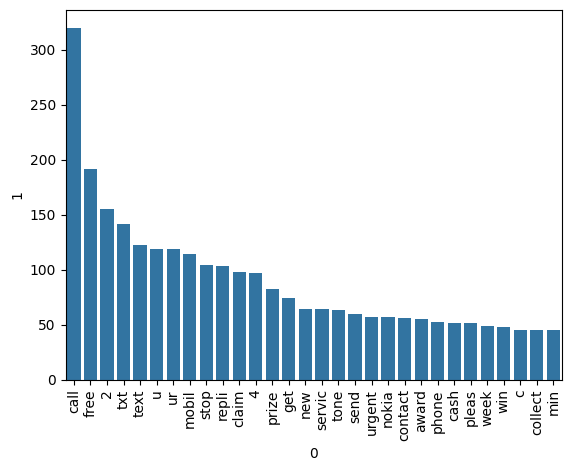

In [110]:
from collections import Counter
sns.barplot(x=pd.DataFrame(Counter(spam_corpus).most_common(30))[0], y=pd.DataFrame(Counter(spam_corpus).most_common(30))[1])
plt.xticks(rotation='vertical')

In [111]:
# Most repeating words in ham messages
ham_corpus = []
for word in spam_data[spam_data['label'] == 0]['Transformed_Message']:
    for i in word.split():
        ham_corpus.append(i)
len(ham_corpus)

35404

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29],
 [Text(0, 0, 'u'),
  Text(1, 0, 'go'),
  Text(2, 0, 'get'),
  Text(3, 0, 'gt'),
  Text(4, 0, 'lt'),
  Text(5, 0, '2'),
  Text(6, 0, 'come'),
  Text(7, 0, 'got'),
  Text(8, 0, 'know'),
  Text(9, 0, 'like'),
  Text(10, 0, 'call'),
  Text(11, 0, 'time'),
  Text(12, 0, 'ok'),
  Text(13, 0, 'love'),
  Text(14, 0, 'good'),
  Text(15, 0, 'want'),
  Text(16, 0, 'ur'),
  Text(17, 0, 'day'),
  Text(18, 0, 'need'),
  Text(19, 0, 'one'),
  Text(20, 0, 'lor'),
  Text(21, 0, '4'),
  Text(22, 0, 'home'),
  Text(23, 0, 'think'),
  Text(24, 0, 'see'),
  Text(25, 0, 'take'),
  Text(26, 0, 'still'),
  Text(27, 0, 'da'),
  Text(28, 0, 'tell'),
  Text(29, 0, 'make')])

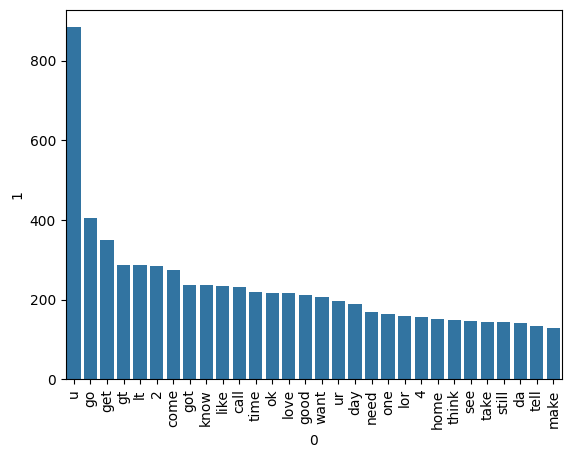

In [112]:
from collections import Counter
sns.barplot(x=pd.DataFrame(Counter(ham_corpus).most_common(30))[0], y=pd.DataFrame(Counter(ham_corpus).most_common(30))[1])
plt.xticks(rotation='vertical')

# 4.Model Building

In [113]:
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer
cv = CountVectorizer()
tfidf = TfidfVectorizer(max_features=3000)

In [114]:
X = tfidf.fit_transform(spam_data['Transformed_Message']).toarray()

In [115]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X = scaler.fit_transform(X)

In [116]:
# Appedning the num of characters, words and sentences to the feature set
X = np.hstack((X, spam_data['num_chars'].values.reshape(-1, 1), spam_data['num_words'].values.reshape(-1, 1), spam_data['num_sents'].values.reshape(-1, 1)))

In [117]:
X.shape

(5169, 3003)

In [118]:
y = spam_data['label'].values
y

array([0, 0, 1, ..., 0, 0, 0], shape=(5169,))

In [119]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

In [120]:
from sklearn.naive_bayes import MultinomialNB,GaussianNB, BernoulliNB
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score
mnb = MultinomialNB()
gnb = GaussianNB()
bnb = BernoulliNB()


In [121]:
mnb.fit(X_train, y_train)
y_pred_mnb = mnb.predict(X_test)
print(accuracy_score(y_test, y_pred_mnb))
print(confusion_matrix(y_test, y_pred_mnb))
print(precision_score(y_test, y_pred_mnb))

0.9738878143133463
[[891   5]
 [ 22 116]]
0.9586776859504132


In [122]:
gnb.fit(X_train, y_train)
y_pred_gnb = gnb.predict(X_test)
print(accuracy_score(y_test, y_pred_gnb))
print(confusion_matrix(y_test, y_pred_gnb))
print(precision_score(y_test, y_pred_gnb))

0.8945841392649904
[[802  94]
 [ 15 123]]
0.5668202764976958


In [123]:
bnb.fit(X_train, y_train)
y_pred_bnb = bnb.predict(X_test)    
print(accuracy_score(y_test, y_pred_bnb))
print(confusion_matrix(y_test, y_pred_bnb))
print(precision_score(y_test, y_pred_bnb))

0.9835589941972921
[[895   1]
 [ 16 122]]
0.991869918699187


In [124]:
# As preciosion score matters more in here so we will futher use it and here we have use tfidf vectorizer and multinomial naive bayes model as it has the highest precision score.

In [125]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier, ExtraTreesClassifier, BaggingClassifier
from xgboost import XGBClassifier   


In [126]:
svc = SVC(kernel='sigmoid', gamma=1.0)
knc = KNeighborsClassifier()
mnb = MultinomialNB()
dtc = DecisionTreeClassifier(max_depth=5)
lr = LogisticRegression(solver='liblinear', penalty='l1')
rfc = RandomForestClassifier(n_estimators=50, random_state=2)
abc = AdaBoostClassifier(n_estimators=50, random_state=2)
gbc = GradientBoostingClassifier(n_estimators=50, random_state=2)
etc = ExtraTreesClassifier(n_estimators=50, random_state=2)
bc = BaggingClassifier(n_estimators=50, random_state=2)
xgbc = XGBClassifier(n_estimators=50, random_state=2)

In [127]:
# dictionary of all the models where in keys we have the name of the model and in values we have the model with some hyperparameters as well. We will use this dictionary to train and test all the models in one go and then we will compare the results of all the models to find out which model is best for our problem statement.
clfs = {
    "SVC": svc,
    "KNC": knc,
    "MNB": mnb,
    "DTC": dtc,
    "LR": lr,
    "RFC": rfc,
    "ABC": abc,
    "GBC": gbc,
    "ETC": etc,
    "BC": bc,
    "XGBC": xgbc
}

In [128]:
def train_and_evaluate_model(clf, X_train, y_train, X_test, y_test):
    clf.fit(X_train, y_train)  # Train the model
    y_pred = clf.predict(X_test)  # Predict on the test set
    accuracy = accuracy_score(y_test, y_pred)  # Calculate accuracy
    precision = precision_score(y_test, y_pred)  # Calculate precision
    return accuracy, precision

In [129]:
train_and_evaluate_model(svc, X_train, y_train, X_test, y_test)

d:\Educational Data\Data Science Projects\spam classifier\spamvenv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


(0.8665377176015474, 0.0)

In [130]:
accuracy_scores = []
precision_scores = []

for name, clf in clfs.items():
    current_accuracy, current_precision = train_and_evaluate_model(clf, X_train, y_train, X_test, y_test)

    print("For ", name)
    print("Accuracy is ", current_accuracy)
    print("Precision is ", current_precision)

    accuracy_scores.append(current_accuracy)
    precision_scores.append(current_precision)
    

d:\Educational Data\Data Science Projects\spam classifier\spamvenv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


For  SVC
Accuracy is  0.8665377176015474
Precision is  0.0
For  KNC
Accuracy is  0.9264990328820116
Precision is  0.7980769230769231
For  MNB
Accuracy is  0.9738878143133463
Precision is  0.9586776859504132
For  DTC
Accuracy is  0.9448742746615088
Precision is  0.824
For  LR
Accuracy is  0.9642166344294004
Precision is  0.9173553719008265
For  RFC
Accuracy is  0.9729206963249516
Precision is  1.0
For  ABC
Accuracy is  0.9429400386847195
Precision is  0.9072164948453608
For  GBC
Accuracy is  0.9526112185686654
Precision is  0.9494949494949495
For  ETC
Accuracy is  0.9787234042553191
Precision is  0.9833333333333333
For  BC
Accuracy is  0.9690522243713733
Precision is  0.9274193548387096
For  XGBC
Accuracy is  0.9680851063829787
Precision is  0.9487179487179487


In [131]:
performance_spam_data = pd.DataFrame({'Model': clfs.keys(), 'Accuracy': accuracy_scores, 'Precision': precision_scores}).sort_values(by='Precision', ascending=False)
performance_spam_data


,Model,Accuracy,Precision
5,RFC,0.972921,1.000000
8,ETC,0.978723,0.983333
2,MNB,0.973888,0.958678
7,GBC,0.952611,0.949495
10,XGBC,0.968085,0.948718
9,BC,0.969052,0.927419
4,LR,0.964217,0.917355
6,ABC,0.942940,0.907216
3,DTC,0.944874,0.824000
1,KNC,0.926499,0.798077


In [132]:
performance_spam_data_2 = pd.melt(performance_spam_data, id_vars='Model')
performance_spam_data_2

,Model,variable,value
0,RFC,Accuracy,0.972921
1,ETC,Accuracy,0.978723
2,MNB,Accuracy,0.973888
3,GBC,Accuracy,0.952611
4,XGBC,Accuracy,0.968085
5,BC,Accuracy,0.969052
6,LR,Accuracy,0.964217
7,ABC,Accuracy,0.942940
8,DTC,Accuracy,0.944874
9,KNC,Accuracy,0.926499


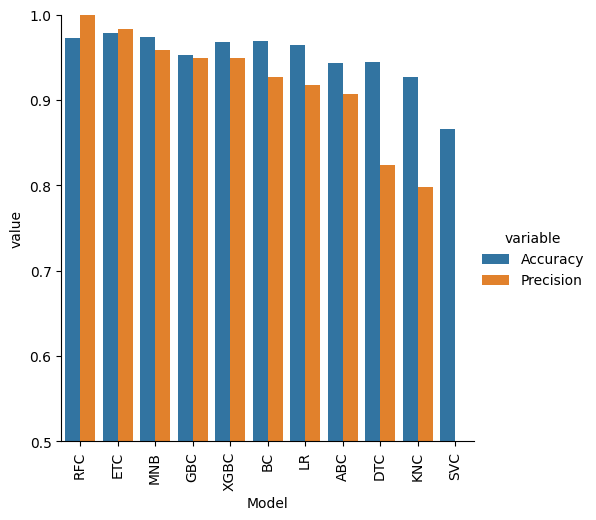

In [133]:
sns.catplot(x='Model', y='value', hue='variable', data=performance_spam_data_2, kind='bar',height = 5)
plt.ylim(0.5,1.0)
plt.xticks(rotation='vertical')
plt.show()

In [134]:
# Model improvement 
# 1.Change the max_features parameter of the tfidf vectorizer to 3000 and see the results.

In [135]:
temp_df = pd.DataFrame({'Model': clfs.keys(), 'Accuracy_max_features_3000': accuracy_scores, 'Precision_max_features_3000': precision_scores})

In [136]:
new_performance = performance_spam_data.merge(temp_df, on='Model')
new_performance_scaled = new_performance.merge(temp_df, on='Model')
new_performance_scaled

,Model,Accuracy,Precision,Accuracy_max_features_3000_x,Precision_max_features_3000_x,Accuracy_max_features_3000_y,Precision_max_features_3000_y
0,RFC,0.972921,1.000000,0.972921,1.000000,0.972921,1.000000
1,ETC,0.978723,0.983333,0.978723,0.983333,0.978723,0.983333
2,MNB,0.973888,0.958678,0.973888,0.958678,0.973888,0.958678
3,GBC,0.952611,0.949495,0.952611,0.949495,0.952611,0.949495
4,XGBC,0.968085,0.948718,0.968085,0.948718,0.968085,0.948718
5,BC,0.969052,0.927419,0.969052,0.927419,0.969052,0.927419
6,LR,0.964217,0.917355,0.964217,0.917355,0.964217,0.917355
7,ABC,0.942940,0.907216,0.942940,0.907216,0.942940,0.907216
8,DTC,0.944874,0.824000,0.944874,0.824000,0.944874,0.824000
9,KNC,0.926499,0.798077,0.926499,0.798077,0.926499,0.798077


In [137]:
import pickle

In [138]:
pickle.dump(tfidf, open('vectorizer.pkl', 'wb'))
pickle.dump(mnb, open('model.pkl', 'wb'))